In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import json
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon

plt.rcParams.update({
    "text.usetex": True,
    "font.size": 20,
})

In [3]:
methods = ["TTS", "Waveform", "SMACK", "PGD"]
paths = ["../outputs/results/" + m for m in methods[:-1]]
results = [dict() for _ in methods]

## Runtime & Budget

In [4]:
jsons = [glob(p + "/**/**/**/*.json") for p in paths[:-1]] + [glob(paths[-1] + "/**/**/*.json")] + [glob("../outputs/harvard_sentence_*/pgd.json")]

In [5]:
for m, j, r in zip(methods, jsons, results):
    times, budget = [], []
    for file in j:
        with open(file, "r") as f:
            d = json.load(f)

        if "efficiency_metrics" in d.keys():
            times.append(d["efficiency_metrics"]["elapsed_time_seconds"])
            budget.append(d["efficiency_metrics"]["generation_count"] * d["algorithm_parameters"]["pop_size"])
        elif "efficiency" in d.keys():
            times.append(d["efficiency"]["elapsed_time_seconds"])
            budget.append(d["efficiency"]["num_generations"] * d["efficiency"]["pop_size"])
        else:
            times.append(d["elapsed_seconds"])
            budget.append(d["params"]["num_generations"]*d["params"]["pop_size"])

        r |= {"runt": times, "budget": budget}
    print(f"{m} - Runtime: {np.mean(times):.2f} pm {np.std(times):.2f} s")
    print(f"{m} - Budget: {np.mean(budget):.2f} pm {np.std(budget):.2f}")

TTS - Runtime: 222.43 pm 168.00 s
TTS - Budget: 5067.33 pm 3752.31
Waveform - Runtime: 361.69 pm 285.16 s
Waveform - Budget: 7039.00 pm 4151.12
SMACK - Runtime: 223.73 pm 48.80 s
SMACK - Budget: 300.00 pm 0.00
PGD - Runtime: 15.85 pm 1.27 s
PGD - Budget: 200.00 pm 0.00


    ## Statistical Test

In [9]:
alternative = {
    "runt": "less",
    "budget": "less",
}

In [10]:
def cohens_d_paired(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    n = min(len(a), len(b))
    diff = a[:n] - b[:n]
    return abs(np.mean(diff) / np.std(diff, ddof=1))

In [11]:
for i, m in enumerate(results[1:], 1):
    print(f"TTS vs {methods[i]}")
    for k, vals in results[0].items():
        stat, p = wilcoxon(vals[:100], m[k][:100], alternative=alternative[k])
        d = cohens_d_paired(vals[:100], m[k][:100])
        print(f"\t{k}: p={p:.3e}; Cohens-D: {d:.1f}")

TTS vs Waveform
	runt: p=4.940e-04; Cohens-D: 0.4
	budget: p=2.184e-03; Cohens-D: 0.3
TTS vs PGD
	runt: p=1.000e+00; Cohens-D: 1.2
	budget: p=1.000e+00; Cohens-D: 1.3


## Convergence Plot

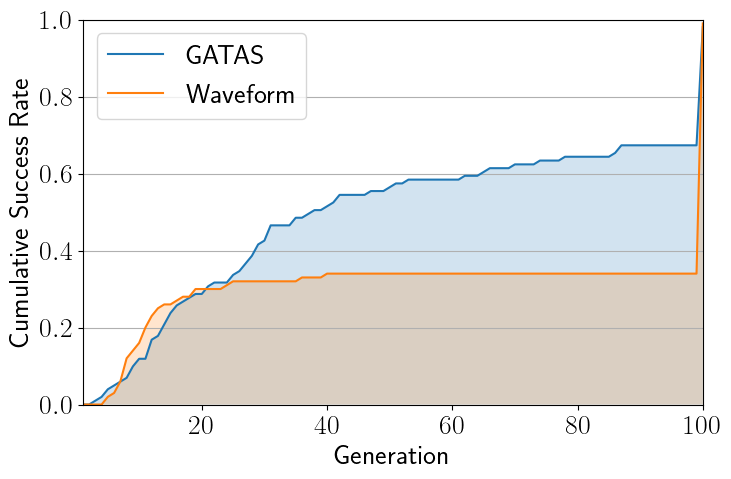

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
gens = np.arange(1, 101)

for method, files in zip(methods[:-2], jsons):
    curves = []
    for file in files:
        with open(file, "r") as f:
            d = json.load(f)
        elems = d.get("success_metrics", False)
        if d["text_data"].get("whisper_transcription"):
            found = d["text_data"]["gt_transcription"].lower().strip() != d["text_data"]["whisper_transcription"].lower().strip()
        else:
            found = d["text_data"]["gt_transcription"].lower().strip() != d["text_data"]["asr_transcription"].lower().strip()
        at_gen = int(d["efficiency_metrics"]["generation_count"] if "efficiency_metrics" in d.keys() else d["efficiency"]["num_generations"])

        if found:
            cumul = (gens >= at_gen).astype(float)
        else:
            cumul = np.zeros_like(gens, dtype=float)
        curves.append(cumul)

    X = np.vstack(curves)
    mean = np.nanmean(X, axis=0)

    method = "GATAS" if method is "TTS" else method
    ax.plot(gens, mean, label=method)
    ax.fill_between(gens, 0, mean, alpha=0.2)

ax.set_xlabel("Generation")
ax.set_ylabel("Cumulative Success Rate")
ax.set_xlim(1, 100)
ax.set_ylim(0, 1)
ax.legend()
ax.legend(loc="upper left")
ax.grid(axis="y")
ax.set_xlim([1,100])

plt.savefig("_figures/convergance.pdf", dpi=200, bbox_inches="tight")